# B1 — ResNet50 + MC Dropout (T=30) experiment pipeline

- ResNet50 backbone
- standard softmax cross-entropy
- MC Dropout, **T=30**
- dropout **p=0.5** immediately before the final classifier
- 3 classes: benign / indeterminate / malignant
- 224×224 grayscale input replicated to 3 channels
- AdamW (β1=0.9, β2=0.999, weight decay=0.01)
- cosine annealing 1e-4 → 1e-6
- max 50 epochs
- early stopping patience 10 on validation Brier Score
- patient-level 5-fold cross-validation
- 10% of training patients reserved for validation where feasible
- seed 42
- evaluation: Macro-F1, macro OVR AUROC, Brier Score, ECE (15 bins), NLL
- MC predictive entropy uncertainty + rejection curves
- Grad-CAM
- latency, FLOPs, parameter count
- fold-wise outputs and 5-fold mean ± SD
- Wilcoxon comparison helper for later B1-vs-B3/C1 comparisons

### 50-patient pilot
The notebook is safe for your current 20-patient subset. If strict stratification is impossible because one class has too few patients, it falls back to a **patient-disjoint** split and records the limitation rather than leaking patches across splits.

### XAI mask requirement
Grad-CAM images can be generated from patches alone. Pointing Game, Insertion/Deletion AUC, and boundary-distance evaluation require **patch-aligned radiologist contour masks**. If a `mask_path` column is later added to metadata, the notebook can evaluate them; otherwise it records those metrics as unavailable.

In [ ]:
#@title 1. Install dependencies
!pip -q install scikit-learn scipy matplotlib pandas pillow tqdm thop

In [ ]:
#@title 2. Imports and global configuration
import os, json, math, time, copy, random, warnings, gc
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy.stats import wilcoxon

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import ResNet50_Weights

from sklearn.model_selection import StratifiedGroupKFold, GroupKFold, StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, log_loss, confusion_matrix
from sklearn.preprocessing import label_binarize
from tqdm.auto import tqdm
from thop import profile

warnings.filterwarnings('ignore')

PILOT_MAX_PATIENTS = 50   # set to None for the full dataset
SEED = 42
NUM_CLASSES = 3
CLASS_NAMES = ['benign', 'indeterminate', 'malignant']
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
MAX_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 10
LEARNING_RATE = 1e-4
MIN_LEARNING_RATE = 1e-6
WEIGHT_DECAY = 0.01
MC_T = 30
DROPOUT_P = 0.5
ECE_BINS = 15

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [ ]:
#@title 3. Reproducibility
def seed_everything(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass
seed_everything(SEED)

In [ ]:
#@title 4. Mount Google Drive and create the agreed shared folder structure
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = Path('/content/drive/MyDrive/LIDC_Thesis')
LIDC_ROOT = PROJECT_ROOT / 'LIDC'
PROCESSED_ROOT = LIDC_ROOT / 'processed'
PATCH_ROOT = PROCESSED_ROOT / 'patches'
METADATA_ROOT = PROCESSED_ROOT / 'metadata'

B1_ROOT = PROJECT_ROOT / 'experiments' / 'B1_ResNet50_MC_Dropout_T30'
NOTEBOOK_ROOT = B1_ROOT / 'notebooks'
CONFIG_ROOT = B1_ROOT / 'configs'
SPLIT_ROOT = B1_ROOT / 'splits'
CHECKPOINT_ROOT = B1_ROOT / 'checkpoints'
PREDICTION_ROOT = B1_ROOT / 'predictions'
METRICS_ROOT = B1_ROOT / 'metrics'
GRADCAM_ROOT = B1_ROOT / 'gradcam'
PLOT_ROOT = B1_ROOT / 'plots'
LOG_ROOT = B1_ROOT / 'logs'
REPORT_ROOT = B1_ROOT / 'reports'

for p in [NOTEBOOK_ROOT, CONFIG_ROOT, SPLIT_ROOT, CHECKPOINT_ROOT, PREDICTION_ROOT,
          METRICS_ROOT, GRADCAM_ROOT, PLOT_ROOT, LOG_ROOT, REPORT_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

METADATA_CSV = METADATA_ROOT / 'lidc_patches_metadata.csv'
DETAILED_METADATA_CSV = METADATA_ROOT / 'lidc_patches_metadata_detailed.csv'
print('PATCH_ROOT:', PATCH_ROOT)
print('B1_ROOT:', B1_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PATCH_ROOT: /content/drive/MyDrive/LIDC_Thesis/LIDC/processed/patches
B1_ROOT: /content/drive/MyDrive/LIDC_Thesis/experiments/B1_ResNet50_MC_Dropout_T30



## 5. Expected individual patch organization

The preprocessing notebook stores **one file per nodule**:

```text
MyDrive/LIDC_Thesis/LIDC/processed/patches/
├── benign/<patient_id>/<nodule_id>.png
├── indeterminate/<patient_id>/<nodule_id>.png
└── malignant/<patient_id>/<nodule_id>.png
```

Canonical metadata:

```text
image_path,patient_id,label,class_name,nodule_id,...
...
```

Labels: `0=benign`, `1=indeterminate`, `2=malignant`.

This notebook uses individual image files directly. **No `.npz` file is loaded or required.**

If an old/incompatible metadata CSV is present, the next cell safely rebuilds the required
metadata from the class/patient patch folders instead of raising a `KeyError`.


In [ ]:

#@title 6. Load metadata for INDIVIDUAL patch files only
LABEL_MAP = {'benign':0, 'indeterminate':1, 'malignant':2}
INV_LABEL_MAP = {v:k for k,v in LABEL_MAP.items()}

IMAGE_EXTS = {'.png','.jpg','.jpeg','.tif','.tiff','.bmp'}

def rebuild_metadata_from_patches(root):
    """
    Rebuild metadata directly from:
      patches/<class_name>/<patient_id>/<individual image file>
    """
    rows = []
    root = Path(root)

    for class_name, label in LABEL_MAP.items():
        cdir = root / class_name
        if not cdir.exists():
            continue

        for fp in cdir.rglob('*'):
            if not fp.is_file() or fp.suffix.lower() not in IMAGE_EXTS:
                continue

            rel = fp.relative_to(cdir)
            if len(rel.parts) >= 2:
                patient_id = rel.parts[0]
            else:
                # Last-resort compatibility for flat class folders.
                # Standard preprocessing always creates a patient subfolder.
                patient_id = fp.stem.split('_N')[0]

            rows.append({
                'image_path': str(fp),
                'patient_id': str(patient_id),
                'label': int(label),
                'class_name': class_name,
                'nodule_id': fp.stem,
            })

    return pd.DataFrame(rows)

def normalize_metadata_schema(frame):
    """
    Accept the canonical preprocessing schema and a few harmless historical aliases.
    If the loaded CSV is unrelated/incompatible, return None so we rebuild safely
    from the individual patch folders instead of failing with KeyError.
    """
    if frame is None or len(frame) == 0:
        return None

    frame = frame.copy()
    frame.columns = [str(c).strip() for c in frame.columns]

    aliases = {
        'patient_id': ['patient_id', 'PatientID', 'patient', 'patientId', 'patientID'],
        'image_path': ['image_path', 'patch_path', 'filepath', 'file_path', 'path'],
        'label': ['label', 'label_id', 'class_id', 'target'],
        'class_name': ['class_name', 'label_name', 'class'],
    }

    rename = {}
    for canonical, candidates in aliases.items():
        if canonical in frame.columns:
            continue
        found = next((c for c in candidates if c in frame.columns), None)
        if found is not None:
            rename[found] = canonical

    frame = frame.rename(columns=rename)

    # If only class_name exists, derive numeric label.
    if 'label' not in frame.columns and 'class_name' in frame.columns:
        frame['label'] = frame['class_name'].astype(str).str.lower().map(LABEL_MAP)

    # If only label exists, derive class_name.
    if 'class_name' not in frame.columns and 'label' in frame.columns:
        numeric = pd.to_numeric(frame['label'], errors='coerce')
        frame['class_name'] = numeric.map(INV_LABEL_MAP)

    required = {'image_path', 'patient_id', 'label'}
    if not required.issubset(frame.columns):
        return None

    return frame

# First try the authoritative preprocessing metadata.
df = None
if METADATA_CSV.exists():
    loaded = pd.read_csv(METADATA_CSV)
    print('Loaded metadata:', METADATA_CSV)
    print('Columns found:', loaded.columns.tolist())
    df = normalize_metadata_schema(loaded)

    if df is None:
        print(
            "Existing metadata CSV does not have a compatible individual-patch schema. "
            "Rebuilding metadata from patch folders instead."
        )

# Safe fallback: discover the individual patch files directly.
if df is None:
    df = rebuild_metadata_from_patches(PATCH_ROOT)

if df is None or len(df) == 0:
    raise RuntimeError(
        f"No individual patch images were found under {PATCH_ROOT}. "
        "Run the updated preprocessing patch-extraction/export cells first."
    )

# Canonical types.
df['patient_id'] = df['patient_id'].astype(str).str.strip()
df['label'] = pd.to_numeric(df['label'], errors='raise').astype(int)
df['image_path'] = df['image_path'].astype(str)

if 'class_name' not in df.columns:
    df['class_name'] = df['label'].map(INV_LABEL_MAP)
else:
    df['class_name'] = df['class_name'].astype(str).str.lower()

# Retain only the three valid classes.
df = df[df['label'].isin([0,1,2])].copy()

# Keep only real individual image files.
exists_mask = df['image_path'].map(lambda p: Path(p).is_file())
if (~exists_mask).any():
    print(f"Dropping {(~exists_mask).sum()} metadata row(s) whose patch file does not exist.")
df = df[exists_mask].drop_duplicates('image_path').reset_index(drop=True)

if PILOT_MAX_PATIENTS is not None:
    chosen = sorted(df['patient_id'].unique())[:PILOT_MAX_PATIENTS]
    df = df[df['patient_id'].isin(chosen)].reset_index(drop=True)

if len(df) == 0:
    raise RuntimeError('No valid individual patch images remained after metadata validation.')

print('Patches:', len(df))
print('Patients:', df['patient_id'].nunique())
print(df['class_name'].value_counts())

# Save exactly what B1 actually used.
df.to_csv(METADATA_ROOT / 'B1_effective_metadata.csv', index=False)


Loaded metadata: /content/drive/MyDrive/LIDC_Thesis/LIDC/processed/metadata/lidc_patches_metadata.csv
Columns found: ['image_path', 'patient_id', 'label']
Existing metadata CSV does not have a compatible individual-patch schema. Rebuilding metadata from patch folders instead.
Patches: 94
Patients: 38
class_name
indeterminate    54
malignant        21
benign           19
Name: count, dtype: int64


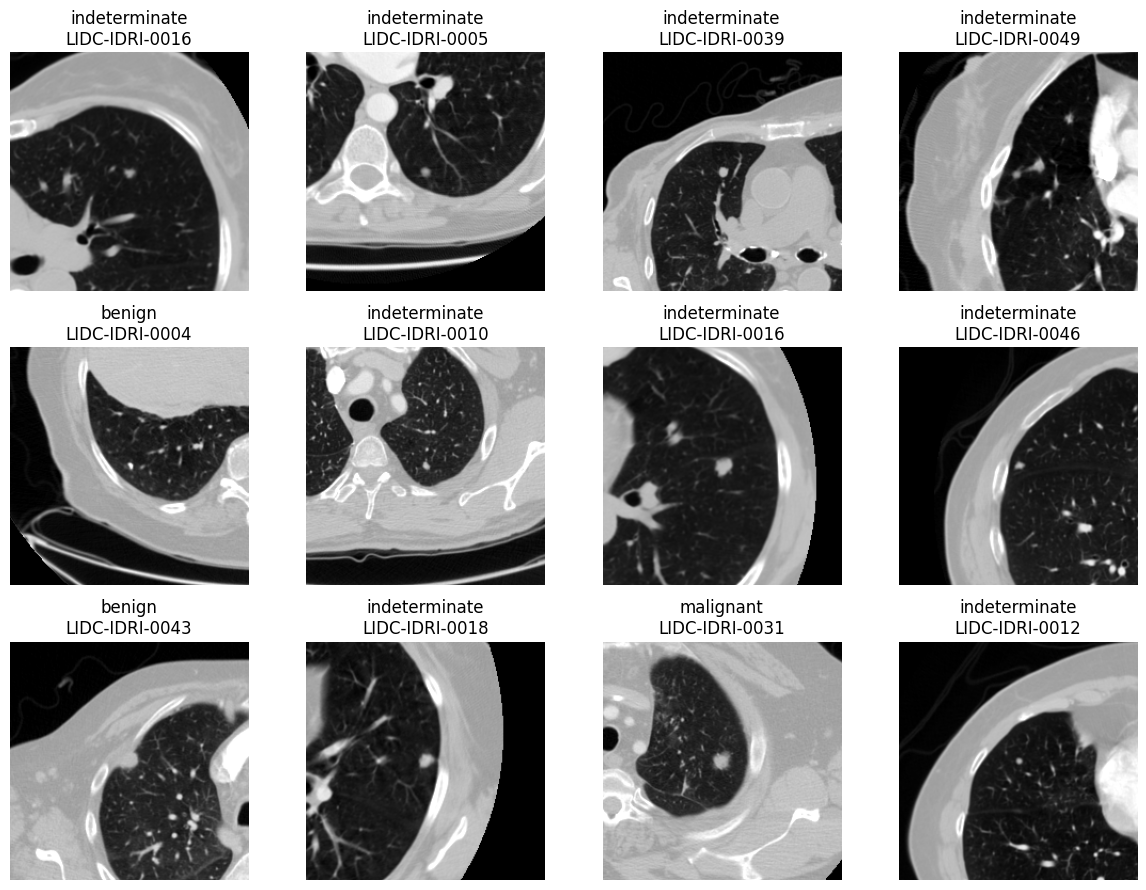

In [ ]:
#@title 7. Optional: inspect sample images
def show_samples(df, n=12):
    sample = df.sample(min(n, len(df)), random_state=SEED)
    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    axes = np.asarray(axes).reshape(-1)

    for ax, (_, row) in zip(axes, sample.iterrows()):
        img = Image.open(row["image_path"]).convert("L")
        ax.imshow(img, cmap="gray")
        ax.set_title(f'{CLASS_NAMES[int(row["label"])]}\n{row["patient_id"]}')
        ax.axis("off")

    for ax in axes[len(sample):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_samples(df)


In [ ]:
#@title 8. Dataset and transforms
# Proposal specifies 224x224 grayscale replicated to 3 channels.
# No extra augmentation is enabled here
base_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

class LIDCPatchDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df=dataframe.reset_index(drop=True).copy()
        self.transform=transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row=self.df.iloc[idx]
        with Image.open(row['image_path']) as img:
            img=img.convert('L')
            x=self.transform(img) if self.transform else transforms.ToTensor()(img)
        item={'image':x,'label':torch.tensor(int(row['label']),dtype=torch.long),
              'patient_id':str(row['patient_id']),'image_path':str(row['image_path'])}
        if 'mask_path' in self.df.columns:
            item['mask_path']=str(row.get('mask_path',''))
        return item

In [ ]:
#@title 9. Patient-level 5-fold split + patient-level validation split

def make_outer_splits(df,n_splits=5):
    X=np.zeros((len(df),1)); y=df['label'].values; groups=df['patient_id'].values
    try:
        sp=StratifiedGroupKFold(n_splits=n_splits,shuffle=True,random_state=SEED)
        splits=list(sp.split(X,y,groups)); method='StratifiedGroupKFold'
    except Exception as e:
        print('StratifiedGroupKFold unavailable for this pilot:',repr(e))
        sp=GroupKFold(n_splits=n_splits)
        splits=list(sp.split(X,y,groups)); method='GroupKFold fallback'
    return splits,method

def dominant_patient_labels(frame):
    return frame.groupby('patient_id')['label'].agg(lambda s:int(s.value_counts().index[0]))

def split_train_val_patients(trainval_df, fraction=0.10, seed=42):
    ptab=dominant_patient_labels(trainval_df)
    patients=ptab.index.to_numpy(); labels=ptab.values
    n=len(patients); n_val=max(1,min(n-1,int(round(n*fraction))))
    counts=Counter(labels)
    can_stratify=(len(counts)>=2 and min(counts.values())>=2 and n_val>=len(counts))
    if can_stratify:
        sss=StratifiedShuffleSplit(n_splits=1,test_size=n_val,random_state=seed)
        ti,vi=next(sss.split(patients,labels)); method='patient-stratified'
        trp=set(patients[ti]); vap=set(patients[vi])
    else:
        rng=np.random.RandomState(seed); shuffled=patients.copy(); rng.shuffle(shuffled)
        vap=set(shuffled[:n_val]); trp=set(shuffled[n_val:]); method='patient-random fallback'
    return (trainval_df[trainval_df.patient_id.isin(trp)].copy(),
            trainval_df[trainval_df.patient_id.isin(vap)].copy(),method)

outer_splits,outer_method=make_outer_splits(df,5)
print('Outer split:',outer_method)
folds=[]; manifest=[]
for fold,(trainval_idx,test_idx) in enumerate(outer_splits):
    trainval=df.iloc[trainval_idx].copy(); test=df.iloc[test_idx].copy()
    train,val,val_method=split_train_val_patients(trainval,0.10,SEED+fold)
    assert set(train.patient_id).isdisjoint(set(val.patient_id))
    assert set(train.patient_id).isdisjoint(set(test.patient_id))
    assert set(val.patient_id).isdisjoint(set(test.patient_id))
    info={'fold':fold,'train':train.reset_index(drop=True),'val':val.reset_index(drop=True),'test':test.reset_index(drop=True)}
    folds.append(info)
    for name,frame in [('train',train),('val',val),('test',test)]:
        frame.to_csv(SPLIT_ROOT/f'fold_{fold}_{name}.csv',index=False)
        manifest.append({'fold':fold,'split':name,'patches':len(frame),'patients':frame.patient_id.nunique(),
                         'benign':int((frame.label==0).sum()),'indeterminate':int((frame.label==1).sum()),
                         'malignant':int((frame.label==2).sum()),'val_method':val_method if name!='test' else ''})
manifest_df=pd.DataFrame(manifest); manifest_df.to_csv(SPLIT_ROOT/'split_manifest.csv',index=False)
display(manifest_df)

Outer split: StratifiedGroupKFold


,fold,split,patches,patients,benign,indeterminate,malignant,val_method
0,0,train,66,29,10,39,17,patient-stratified
1,0,val,9,3,4,4,1,patient-stratified
2,0,test,19,6,5,11,3,
3,1,train,65,26,13,37,15,patient-stratified
4,1,val,7,3,2,4,1,patient-stratified
5,1,test,22,9,4,13,5,
6,2,train,56,26,12,29,15,patient-stratified
7,2,val,15,3,0,13,2,patient-stratified
8,2,test,23,9,7,12,4,
9,3,train,70,28,16,39,15,patient-stratified


In [ ]:
#@title 10. DataLoader construction
def make_loaders(train_df,val_df,test_df):
    kwargs=dict(batch_size=BATCH_SIZE,num_workers=NUM_WORKERS,pin_memory=torch.cuda.is_available())
    return (DataLoader(LIDCPatchDataset(train_df,base_transform),shuffle=True,**kwargs),
            DataLoader(LIDCPatchDataset(val_df,base_transform),shuffle=False,**kwargs),
            DataLoader(LIDCPatchDataset(test_df,base_transform),shuffle=False,**kwargs))

In [ ]:
#@title 11. B1 ResNet50 with dropout before the final classifier
class ResNet50MCDropout(nn.Module):
    def __init__(self, num_classes=3, dropout_p=0.5, pretrained=True):
        super().__init__()

        weights = ResNet50_Weights.DEFAULT if pretrained else None
        self.backbone = models.resnet50(weights=weights)

        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(p=dropout_p),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

    def enable_dropout(self):
        # Enable dropout layers while preserving BatchNorm evaluation behavior.
        for module in self.modules():
            if isinstance(module, nn.Dropout):
                module.train()

model = ResNet50MCDropout(
    num_classes=NUM_CLASSES,
    dropout_p=DROPOUT_P,
    pretrained=True
).to(DEVICE)

print(model.backbone.fc)


Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=2048, out_features=3, bias=True)
)


In [ ]:
#@title 12. Required evaluation metrics

EPS=1e-12

def multiclass_brier_score(y_true,probs):
    oh=np.eye(NUM_CLASSES)[np.asarray(y_true,dtype=int)]
    return float(np.mean(np.sum((np.asarray(probs)-oh)**2,axis=1)))

def expected_calibration_error(y_true,probs,n_bins=15):
    y_true=np.asarray(y_true); probs=np.asarray(probs)
    conf=probs.max(1); pred=probs.argmax(1); correct=(pred==y_true).astype(float)
    edges=np.linspace(0,1,n_bins+1); ece=0.0
    for i,(lo,hi) in enumerate(zip(edges[:-1],edges[1:])):
        m=(conf>=lo)&(conf<=hi) if i==0 else (conf>lo)&(conf<=hi)
        if m.any(): ece+=m.mean()*abs(correct[m].mean()-conf[m].mean())
    return float(ece)

def safe_macro_auroc(y_true,probs):
    y=np.asarray(y_true,dtype=int); p=np.asarray(probs)
    yb=label_binarize(y,classes=[0,1,2]); vals=[]
    for k in range(NUM_CLASSES):
        if len(np.unique(yb[:,k]))<2: vals.append(np.nan)
        else: vals.append(roc_auc_score(yb[:,k],p[:,k]))
    return float(np.nanmean(vals)) if np.isfinite(vals).any() else np.nan

def compute_classification_metrics(y_true,probs):
    y=np.asarray(y_true,dtype=int); p=np.asarray(probs,dtype=float); pred=p.argmax(1)
    return {'accuracy':float(accuracy_score(y,pred)),
            'macro_f1':float(f1_score(y,pred,average='macro',zero_division=0)),
            'auroc_ovr_macro':safe_macro_auroc(y,p),
            'brier_score':multiclass_brier_score(y,p),
            'ece_15':expected_calibration_error(y,p,ECE_BINS),
            'nll':float(-np.mean(np.log(np.clip(p[np.arange(len(y)),y],EPS,1.0))))}

In [ ]:
#@title 13. Training and validation utilities
def standard_forward(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_labels, all_probs = [], []

    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(DEVICE, non_blocking=True)
            labels = batch["label"].to(DEVICE, non_blocking=True)

            logits = model(images)
            loss = criterion(logits, labels)
            probs = torch.softmax(logits, dim=1)

            total_loss += loss.item() * images.size(0)
            all_labels.extend(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    probabilities = np.concatenate(all_probs, axis=0)
    labels = np.asarray(all_labels)
    avg_loss = total_loss / len(loader.dataset)
    metrics = compute_classification_metrics(labels, probabilities)
    metrics["loss"] = float(avg_loss)
    return metrics, labels, probabilities

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0

    for batch in loader:
        images = batch["image"].to(DEVICE, non_blocking=True)
        labels = batch["label"].to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    return running_loss / len(loader.dataset)


In [ ]:
#@title 14. Train one fold with AdamW, cosine annealing, and Brier-based early stopping
def train_fold(train_loader, val_loader, fold_number, run_dir):
    model = ResNet50MCDropout(
        num_classes=NUM_CLASSES,
        dropout_p=DROPOUT_P,
        pretrained=True
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        betas=(0.9, 0.999),
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=MAX_EPOCHS,
        eta_min=MIN_LEARNING_RATE
    )

    history = []
    best_state = None
    best_val_brier = float("inf")
    epochs_without_improvement = 0

    run_dir.mkdir(parents=True, exist_ok=True)

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_metrics, _, _ = standard_forward(model, val_loader, criterion)
        scheduler.step()

        record = {
            "epoch": epoch,
            "train_loss": float(train_loss),
            "learning_rate": float(optimizer.param_groups[0]["lr"]),
            **{f"val_{k}": v for k, v in val_metrics.items()}
        }
        history.append(record)

        print(
            f"Fold {fold_number} | Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} | "
            f"val_brier={val_metrics['brier_score']:.4f} | "
            f"val_macro_f1={val_metrics['macro_f1']:.4f}"
        )

        if val_metrics["brier_score"] < best_val_brier:
            best_val_brier = val_metrics["brier_score"]
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0

            torch.save(
                {
                    "fold": fold_number,
                    "epoch": epoch,
                    "model_state_dict": best_state,
                    "best_val_brier": best_val_brier,
                    "config": {
                        "backbone": "ResNet50",
                        "dropout_p": DROPOUT_P,
                        "mc_t": MC_T,
                        "seed": SEED
                    }
                },
                CHECKPOINT_ROOT / f"fold_{fold_number}_best.pt"
            )
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print("Early stopping triggered.")
            break

    model.load_state_dict(best_state)
    pd.DataFrame(history).to_csv(LOG_ROOT / f"fold_{fold_number}_history.csv", index=False)
    return model, pd.DataFrame(history)


In [ ]:
#@title 15. MC Dropout inference (T=30)
def enable_mc_dropout(model):
    model.eval()
    for m in model.modules():
        if isinstance(m,nn.Dropout): m.train()

@torch.no_grad()
def mc_dropout_predict(model,loader,T=30):
    enable_mc_dropout(model)
    passes=[]; labels=None; metadata=None
    for t in tqdm(range(T),desc=f'MC Dropout T={T}',leave=False):
        pp=[]; yy=[]; mm=[]
        for batch in loader:
            x=batch['image'].to(DEVICE,non_blocking=True)
            probs=torch.softmax(model(x),1).cpu().numpy(); pp.append(probs)
            if t==0:
                yy.extend(batch['label'].numpy().tolist())
                mm.extend([{'patient_id':p,'image_path':q} for p,q in zip(batch['patient_id'],batch['image_path'])])
        passes.append(np.concatenate(pp,0))
        if t==0: labels=np.asarray(yy); metadata=mm
    mc=np.stack(passes,0); mean=mc.mean(0)
    pred_ent=-np.sum(np.clip(mean,EPS,1)*np.log(np.clip(mean,EPS,1)),axis=1)
    exp_ent=-np.mean(np.sum(np.clip(mc,EPS,1)*np.log(np.clip(mc,EPS,1)),axis=2),axis=0)
    mi=pred_ent-exp_ent
    prob_var=mc.var(0).mean(1)
    plabel=mc.argmax(2); vr=[]
    for i in range(plabel.shape[1]):
        c=np.bincount(plabel[:,i],minlength=NUM_CLASSES); vr.append(1-c.max()/T)
    return {'mc_probs':mc,'mean_probabilities':mean,'labels':labels,'metadata':metadata,
            'predictive_entropy':pred_ent,'mutual_information':mi,
            'mean_probability_variance':prob_var,'variation_ratio':np.asarray(vr)}

In [ ]:
#@title 16. Save MC predictions and core metrics
def save_mc_results(mc_results,fold_number):
    p=mc_results['mean_probabilities']; y=mc_results['labels']
    metrics=compute_classification_metrics(y,p)
    metrics.update({'mean_predictive_entropy':float(mc_results['predictive_entropy'].mean()),
                    'mean_mutual_information':float(mc_results['mutual_information'].mean()),
                    'mean_probability_variance':float(mc_results['mean_probability_variance'].mean()),
                    'mean_variation_ratio':float(mc_results['variation_ratio'].mean())})
    rows=[]
    for i,m in enumerate(mc_results['metadata']):
        rows.append({'fold':fold_number,'patient_id':m['patient_id'],'image_path':m['image_path'],
                     'true_label':int(y[i]),'predicted_label':int(p[i].argmax()),
                     'p_benign':float(p[i,0]),'p_indeterminate':float(p[i,1]),'p_malignant':float(p[i,2]),
                     'predictive_entropy':float(mc_results['predictive_entropy'][i]),
                     'mutual_information':float(mc_results['mutual_information'][i]),
                     'mean_probability_variance':float(mc_results['mean_probability_variance'][i]),
                     'variation_ratio':float(mc_results['variation_ratio'][i])})
    pred_df=pd.DataFrame(rows)
    pred_df.to_csv(PREDICTION_ROOT/f'fold_{fold_number}_test_predictions.csv',index=False)
    np.savez_compressed(PREDICTION_ROOT/f'fold_{fold_number}_mc_probabilities_T30.npz',
                        mc_probs=mc_results['mc_probs'],mean_probs=p,y_true=y)
    return metrics,pred_df

In [ ]:
#@title 17. Predictive-entropy rejection curve + random rejection lower bound
def rejection_curve(labels,probs,uncertainty):
    y=np.asarray(labels); pred=np.asarray(probs).argmax(1); order=np.argsort(uncertainty)
    rows=[]; n=len(y)
    for kept in range(1,n+1):
        idx=order[:kept]
        rows.append({'coverage':kept/n,'accuracy':float(accuracy_score(y[idx],pred[idx]))})
    return pd.DataFrame(rows)

def random_rejection_curve(labels,probs,repeats=50,seed=42):
    y=np.asarray(labels); pred=np.asarray(probs).argmax(1); n=len(y); rng=np.random.RandomState(seed)
    arr=[]
    for _ in range(repeats):
        o=rng.permutation(n); arr.append([accuracy_score(y[o[:k]],pred[o[:k]]) for k in range(1,n+1)])
    arr=np.asarray(arr)
    return pd.DataFrame({'coverage':np.arange(1,n+1)/n,'accuracy':arr.mean(0),'accuracy_sd':arr.std(0)})

def save_rejection_curves(mc_results,fold):
    a=rejection_curve(mc_results['labels'],mc_results['mean_probabilities'],mc_results['predictive_entropy'])
    r=random_rejection_curve(mc_results['labels'],mc_results['mean_probabilities'],50,SEED+fold)
    a.to_csv(METRICS_ROOT/f'fold_{fold}_rejection_entropy.csv',index=False)
    r.to_csv(METRICS_ROOT/f'fold_{fold}_rejection_random.csv',index=False)
    plt.figure(figsize=(7,5)); plt.plot(a.coverage,a.accuracy,label='MC predictive entropy'); plt.plot(r.coverage,r.accuracy,label='Random')
    plt.xlabel('Coverage'); plt.ylabel('Accuracy'); plt.title(f'Fold {fold} rejection curve'); plt.legend(); plt.tight_layout()
    plt.savefig(PLOT_ROOT/f'fold_{fold}_rejection_curve.png',dpi=160); plt.close()
    auc_entropy=float(np.trapz(a.accuracy.values,a.coverage.values)); auc_random=float(np.trapz(r.accuracy.values,r.coverage.values))
    return {'rejection_auc_entropy':auc_entropy,'rejection_auc_random':auc_random}

In [ ]:
#@title 18. Grad-CAM for ResNet50 (no external Grad-CAM package required)
class GradCAM:
    def __init__(self,model,target_layer):
        self.model=model; self.activations=None; self.gradients=None
        self.h1=target_layer.register_forward_hook(lambda m,i,o:setattr(self,'activations',o))
        self.h2=target_layer.register_full_backward_hook(lambda m,gi,go:setattr(self,'gradients',go[0]))
    def generate(self,x,class_index=None):
        self.model.eval(); logits=self.model(x)
        if class_index is None: class_index=int(logits.argmax(1).item())
        self.model.zero_grad(set_to_none=True); logits[:,class_index].sum().backward()
        w=self.gradients.mean((2,3),keepdim=True); cam=F.relu((w*self.activations).sum(1,keepdim=True))
        cam=F.interpolate(cam,size=(IMG_SIZE,IMG_SIZE),mode='bilinear',align_corners=False)[0,0].detach().cpu().numpy()
        cam-=cam.min(); cam=cam/(cam.max()+1e-12)
        return cam,class_index
    def close(self): self.h1.remove(); self.h2.remove()

def save_gradcams(model,test_df,fold,max_examples=30):
    out=GRADCAM_ROOT/f'fold_{fold}'; out.mkdir(parents=True,exist_ok=True)
    ds=LIDCPatchDataset(test_df,base_transform); gc=GradCAM(model,model.backbone.layer4[-1].conv3); rows=[]
    try:
        for i in range(min(len(ds),max_examples)):
            s=ds[i]; x=s['image'].unsqueeze(0).to(DEVICE); cam,pred=gc.generate(x)
            gray=np.asarray(Image.open(s['image_path']).convert('L').resize((IMG_SIZE,IMG_SIZE)),dtype=float)/255.0
            stem=Path(s['image_path']).stem; npy=out/f'{stem}_gradcam.npy'; png=out/f'{stem}_gradcam.png'; np.save(npy,cam)
            plt.figure(figsize=(5,5)); plt.imshow(gray,cmap='gray'); plt.imshow(cam,cmap='jet',alpha=.45); plt.axis('off')
            plt.title(f"true={CLASS_NAMES[int(s['label'])]} pred={CLASS_NAMES[pred]}"); plt.tight_layout(); plt.savefig(png,dpi=160,bbox_inches='tight'); plt.close()
            rows.append({'fold':fold,'image_path':s['image_path'],'patient_id':s['patient_id'],'true_label':int(s['label']),
                         'predicted_label':pred,'gradcam_png':str(png),'gradcam_npy':str(npy)})
    finally: gc.close()
    pd.DataFrame(rows).to_csv(GRADCAM_ROOT/f'fold_{fold}_gradcam_manifest.csv',index=False)

In [ ]:
#@title 19. Efficiency: parameters, FLOPs, full T=30 latency
def efficiency_metrics(model,test_loader):
    params=sum(p.numel() for p in model.parameters())
    dummy=torch.randn(1,3,IMG_SIZE,IMG_SIZE,device=DEVICE)
    try: flops,_=profile(model,inputs=(dummy,),verbose=False)
    except Exception: flops=np.nan
    single=DataLoader(test_loader.dataset,batch_size=1,shuffle=False,num_workers=0)
    times=[]; enable_mc_dropout(model)
    for j,b in enumerate(single):
        if j>=min(50,len(single.dataset)): break
        x=b['image'].to(DEVICE)
        if torch.cuda.is_available(): torch.cuda.synchronize()
        t0=time.perf_counter()
        with torch.no_grad():
            for _ in range(MC_T): _=model(x)
        if torch.cuda.is_available(): torch.cuda.synchronize()
        times.append((time.perf_counter()-t0)*1000)
    return {'parameter_count':int(params),'single_pass_flops':float(flops) if np.isfinite(flops) else np.nan,
            'mc_dropout_T30_latency_ms_per_image':float(np.mean(times)) if times else np.nan}

In [ ]:
#@title 20. Run all 5 folds
RUN_ALL_FOLDS=True
all_fold_metrics=[]
if RUN_ALL_FOLDS:
    for info in folds:
        fold=info['fold']; print('\n'+'='*72); print('B1 FOLD',fold); print('='*72)
        train_loader,val_loader,test_loader=make_loaders(info['train'],info['val'],info['test'])
        model,history=train_fold(train_loader,val_loader,fold,CHECKPOINT_ROOT)
        mc=mc_dropout_predict(model,test_loader,T=MC_T)
        metrics,pred_df=save_mc_results(mc,fold)
        metrics.update(save_rejection_curves(mc,fold))
        metrics.update(efficiency_metrics(model,test_loader))
        save_gradcams(model,info['test'],fold,max_examples=30)
        metrics.update({'fold':fold,'test_patches':len(info['test']),'test_patients':info['test'].patient_id.nunique(),
                        'xai_quantitative_status':'not_available_no_mask' if 'mask_path' not in info['test'].columns else 'mask_available_not_run'})
        pd.DataFrame([metrics]).to_csv(METRICS_ROOT/f'fold_{fold}_metrics.csv',index=False)
        all_fold_metrics.append(metrics)
        del model; gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()
    results_df=pd.DataFrame(all_fold_metrics); results_df.to_csv(METRICS_ROOT/'B1_fold_metrics.csv',index=False); display(results_df)


B1 FOLD 0
Fold 0 | Epoch 01 | train_loss=1.0606 | val_brier=0.6321 | val_macro_f1=0.2051
Fold 0 | Epoch 02 | train_loss=0.8857 | val_brier=0.6493 | val_macro_f1=0.2051
Fold 0 | Epoch 03 | train_loss=0.7562 | val_brier=0.6680 | val_macro_f1=0.2051
Fold 0 | Epoch 04 | train_loss=0.6813 | val_brier=0.6797 | val_macro_f1=0.2051
Fold 0 | Epoch 05 | train_loss=0.6075 | val_brier=0.6747 | val_macro_f1=0.2051
Fold 0 | Epoch 06 | train_loss=0.5139 | val_brier=0.6715 | val_macro_f1=0.2051
Fold 0 | Epoch 07 | train_loss=0.5008 | val_brier=0.6808 | val_macro_f1=0.2051
Fold 0 | Epoch 08 | train_loss=0.4388 | val_brier=0.6966 | val_macro_f1=0.2051
Fold 0 | Epoch 09 | train_loss=0.3934 | val_brier=0.6876 | val_macro_f1=0.2051
Fold 0 | Epoch 10 | train_loss=0.3766 | val_brier=0.6874 | val_macro_f1=0.2051
Fold 0 | Epoch 11 | train_loss=0.3293 | val_brier=0.7071 | val_macro_f1=0.2051
Early stopping triggered.


MC Dropout T=30:   0%|          | 0/30 [00:00<?, ?it/s]


B1 FOLD 1
Fold 1 | Epoch 01 | train_loss=1.0676 | val_brier=0.6488 | val_macro_f1=0.1481
Fold 1 | Epoch 02 | train_loss=0.9423 | val_brier=0.6398 | val_macro_f1=0.2424
Fold 1 | Epoch 03 | train_loss=0.8375 | val_brier=0.6306 | val_macro_f1=0.2424
Fold 1 | Epoch 04 | train_loss=0.7521 | val_brier=0.6296 | val_macro_f1=0.2424
Fold 1 | Epoch 05 | train_loss=0.6673 | val_brier=0.6247 | val_macro_f1=0.2424
Fold 1 | Epoch 06 | train_loss=0.6123 | val_brier=0.6132 | val_macro_f1=0.2424
Fold 1 | Epoch 07 | train_loss=0.5005 | val_brier=0.6242 | val_macro_f1=0.2424
Fold 1 | Epoch 08 | train_loss=0.4641 | val_brier=0.6298 | val_macro_f1=0.2424
Fold 1 | Epoch 09 | train_loss=0.4253 | val_brier=0.6499 | val_macro_f1=0.2424
Fold 1 | Epoch 10 | train_loss=0.3754 | val_brier=0.6463 | val_macro_f1=0.2424
Fold 1 | Epoch 11 | train_loss=0.3372 | val_brier=0.6488 | val_macro_f1=0.2424
Fold 1 | Epoch 12 | train_loss=0.3231 | val_brier=0.6529 | val_macro_f1=0.2424
Fold 1 | Epoch 13 | train_loss=0.3055 | v

MC Dropout T=30:   0%|          | 0/30 [00:00<?, ?it/s]


B1 FOLD 2
Fold 2 | Epoch 01 | train_loss=1.1207 | val_brier=0.5300 | val_macro_f1=0.4643
Fold 2 | Epoch 02 | train_loss=0.9892 | val_brier=0.4989 | val_macro_f1=0.4643
Fold 2 | Epoch 03 | train_loss=0.8525 | val_brier=0.4726 | val_macro_f1=0.4643
Fold 2 | Epoch 04 | train_loss=0.7303 | val_brier=0.4408 | val_macro_f1=0.4643
Fold 2 | Epoch 05 | train_loss=0.5928 | val_brier=0.4065 | val_macro_f1=0.4643
Fold 2 | Epoch 06 | train_loss=0.4914 | val_brier=0.3764 | val_macro_f1=0.4643
Fold 2 | Epoch 07 | train_loss=0.4192 | val_brier=0.3490 | val_macro_f1=0.4643
Fold 2 | Epoch 08 | train_loss=0.3279 | val_brier=0.3287 | val_macro_f1=0.4643
Fold 2 | Epoch 09 | train_loss=0.2477 | val_brier=0.3141 | val_macro_f1=0.4643
Fold 2 | Epoch 10 | train_loss=0.2197 | val_brier=0.3028 | val_macro_f1=0.4643
Fold 2 | Epoch 11 | train_loss=0.1632 | val_brier=0.2985 | val_macro_f1=0.4643
Fold 2 | Epoch 12 | train_loss=0.1263 | val_brier=0.2916 | val_macro_f1=0.4643
Fold 2 | Epoch 13 | train_loss=0.1133 | v

...


B1 FOLD 3
Fold 3 | Epoch 01 | train_loss=1.0867 | val_brier=0.5747 | val_macro_f1=0.6250
Fold 3 | Epoch 02 | train_loss=0.9448 | val_brier=0.5353 | val_macro_f1=0.4545
Fold 3 | Epoch 03 | train_loss=0.8435 | val_brier=0.5089 | val_macro_f1=0.4545
Fold 3 | Epoch 04 | train_loss=0.7214 | val_brier=0.4918 | val_macro_f1=0.4545
Fold 3 | Epoch 05 | train_loss=0.5965 | val_brier=0.4781 | val_macro_f1=0.4545
Fold 3 | Epoch 06 | train_loss=0.4998 | val_brier=0.4471 | val_macro_f1=0.4545
Fold 3 | Epoch 07 | train_loss=0.4395 | val_brier=0.4216 | val_macro_f1=0.4545
Fold 3 | Epoch 08 | train_loss=0.3558 | val_brier=0.3904 | val_macro_f1=0.4545
Fold 3 | Epoch 09 | train_loss=0.3011 | val_brier=0.3737 | val_macro_f1=0.4545
Fold 3 | Epoch 10 | train_loss=0.2606 | val_brier=0.3654 | val_macro_f1=0.4545
Fold 3 | Epoch 11 | train_loss=0.2397 | val_brier=0.3661 | val_macro_f1=0.4545
Fold 3 | Epoch 12 | train_loss=0.2004 | val_brier=0.3680 | val_macro_f1=0.4545
Fold 3 | Epoch 13 | train_loss=0.1695 | v

MC Dropout T=30:   0%|          | 0/30 [00:00<?, ?it/s]


B1 FOLD 4
Fold 4 | Epoch 01 | train_loss=1.0815 | val_brier=0.6060 | val_macro_f1=0.2727
Fold 4 | Epoch 02 | train_loss=0.9507 | val_brier=0.5659 | val_macro_f1=0.2727
Fold 4 | Epoch 03 | train_loss=0.7976 | val_brier=0.5321 | val_macro_f1=0.2727
Fold 4 | Epoch 04 | train_loss=0.6740 | val_brier=0.5219 | val_macro_f1=0.2727
Fold 4 | Epoch 05 | train_loss=0.5532 | val_brier=0.5089 | val_macro_f1=0.2727
Fold 4 | Epoch 06 | train_loss=0.4639 | val_brier=0.5045 | val_macro_f1=0.2727
Fold 4 | Epoch 07 | train_loss=0.3610 | val_brier=0.5053 | val_macro_f1=0.2727
Fold 4 | Epoch 08 | train_loss=0.2883 | val_brier=0.4983 | val_macro_f1=0.2727
Fold 4 | Epoch 09 | train_loss=0.2232 | val_brier=0.4934 | val_macro_f1=0.2727
Fold 4 | Epoch 10 | train_loss=0.2528 | val_brier=0.4947 | val_macro_f1=0.2727
Fold 4 | Epoch 11 | train_loss=0.1624 | val_brier=0.4883 | val_macro_f1=0.2727
Fold 4 | Epoch 12 | train_loss=0.1263 | val_brier=0.4824 | val_macro_f1=0.2727
Fold 4 | Epoch 13 | train_loss=0.1030 | v

MC Dropout T=30:   0%|          | 0/30 [00:00<?, ?it/s]

,accuracy,macro_f1,auroc_ovr_macro,brier_score,ece_15,nll,mean_predictive_entropy,mean_mutual_information,mean_probability_variance,mean_variation_ratio,rejection_auc_entropy,rejection_auc_random,parameter_count,single_pass_flops,mc_dropout_T30_latency_ms_per_image,fold,test_patches,test_patients,xai_quantitative_status
0,0.578947,0.244444,0.610191,0.601363,0.147911,1.004190,1.075418,0.005541,0.001210,0.057895,0.585749,0.574742,23514179,4.131701e+09,202.014577,0,19,6,not_available_no_mask
1,0.590909,0.247619,0.459900,0.610413,0.269477,1.016722,1.064856,0.003867,0.000866,0.033333,0.497483,0.583101,23514179,4.131701e+09,246.320865,1,22,9,not_available_no_mask
2,0.521739,0.228571,0.389487,0.771189,0.440263,1.327669,0.779379,0.011113,0.002049,0.028986,0.402666,0.511131,23514179,4.131701e+09,259.134913,2,23,9,not_available_no_mask
3,0.416667,0.208333,0.649438,0.708404,0.221251,1.118242,0.836552,0.008963,0.001872,0.041667,0.361851,0.353352,23514179,4.131701e+09,226.811093,3,12,7,not_available_no_mask
4,0.722222,0.419355,0.338462,0.482462,0.242916,0.836074,0.777431,0.012196,0.002195,0.007407,0.606299,0.687720,23514179,4.131701e+09,279.188556,4,18,7,not_available_no_mask


In [ ]:
#@title 21. Five-fold mean ± standard deviation
if RUN_ALL_FOLDS and len(all_fold_metrics):
    results_df=pd.DataFrame(all_fold_metrics)
    rows=[]
    for c in results_df.columns:
        if c=='fold' or not pd.api.types.is_numeric_dtype(results_df[c]): continue
        v=pd.to_numeric(results_df[c],errors='coerce')
        rows.append({'metric':c,'mean':float(v.mean()) if v.notna().any() else np.nan,
                     'std':float(v.std(ddof=1)) if v.notna().sum()>1 else np.nan,'n_valid_folds':int(v.notna().sum())})
    summary_df=pd.DataFrame(rows); summary_df.to_csv(METRICS_ROOT/'B1_5fold_mean_std.csv',index=False); display(summary_df)
    f1mean=float(results_df['macro_f1'].mean())
    milestone={'M2_threshold_macro_f1':0.50,'observed_mean_macro_f1':f1mean,'passed':bool(f1mean>0.50),
               'note':'Pilot interpretation only when PILOT_MAX_PATIENTS=20.'}
    json.dump(milestone,open(REPORT_ROOT/'B1_M2_milestone.json','w'),indent=2); print(milestone)

,metric,mean,std,n_valid_folds
0,accuracy,5.660969e-01,0.111190,5
1,macro_f1,2.696646e-01,0.085117,5
2,auroc_ovr_macro,4.894956e-01,0.135866,5
3,brier_score,6.347661e-01,0.110611,5
4,ece_15,2.643637e-01,0.108220,5
5,nll,1.060580e+00,0.180394,5
6,mean_predictive_entropy,9.067271e-01,0.151097,5
7,mean_mutual_information,8.335909e-03,0.003563,5
8,mean_probability_variance,1.638359e-03,0.000573,5
9,mean_variation_ratio,3.385753e-02,0.018455,5


{'M2_threshold_macro_f1': 0.5, 'observed_mean_macro_f1': 0.2696646185355863, 'passed': False, 'note': 'Pilot interpretation only when PILOT_MAX_PATIENTS=20.'}


In [1]:
#@title 22. Reliability diagram helper (ECE)
def save_reliability_diagram(y_true,probs,fold):
    y=np.asarray(y_true); p=np.asarray(probs); conf=p.max(1); pred=p.argmax(1); correct=(pred==y).astype(float)
    edges=np.linspace(0,1,ECE_BINS+1); xs=[]; ys=[]
    for i,(lo,hi) in enumerate(zip(edges[:-1],edges[1:])):
        m=(conf>=lo)&(conf<=hi) if i==0 else (conf>lo)&(conf<=hi)
        if m.any(): xs.append(conf[m].mean()); ys.append(correct[m].mean())
    plt.figure(figsize=(6,6)); plt.plot([0,1],[0,1],'--',label='Perfect'); plt.plot(xs,ys,marker='o',label='B1 MC Dropout')
    plt.xlabel('Mean confidence'); plt.ylabel('Accuracy'); plt.title(f'Fold {fold} reliability'); plt.legend(); plt.tight_layout()
    plt.savefig(PLOT_ROOT/f'fold_{fold}_reliability.png',dpi=160); plt.close()

# Generate from saved prediction CSVs without rerunning inference.
if RUN_ALL_FOLDS:
    for fold in range(5):
        pth=PREDICTION_ROOT/f'fold_{fold}_test_predictions.csv'
        if pth.exists():
            q=pd.read_csv(pth); probs=q[['p_benign','p_indeterminate','p_malignant']].values
            save_reliability_diagram(q.true_label.values,probs,fold)

NameError: name 'RUN_ALL_FOLDS' is not defined

In [ ]:
#@title 23. Save configuration + Wilcoxon comparison helper
experiment_config={'experiment':'B1_ResNet50_MC_Dropout_T30','backbone':'ResNet50','pretrained':True,
'input_size':[224,224],'grayscale_replicated_to_rgb':True,'num_classes':3,'loss':'CrossEntropyLoss',
'optimizer':'AdamW','adamw_betas':[0.9,0.999],'weight_decay':WEIGHT_DECAY,'initial_learning_rate':LEARNING_RATE,
'minimum_learning_rate':MIN_LEARNING_RATE,'scheduler':'CosineAnnealingLR','max_epochs':MAX_EPOCHS,
'early_stopping_patience':EARLY_STOPPING_PATIENCE,'early_stopping_metric':'validation_brier_score',
'dropout_probability':DROPOUT_P,'mc_dropout_T':MC_T,'seed':SEED,'batch_size':BATCH_SIZE,'ece_bins':ECE_BINS,
'pilot_max_patients':PILOT_MAX_PATIENTS}
json.dump(experiment_config,open(CONFIG_ROOT/'B1_config.json','w'),indent=2)

def wilcoxon_metric_comparison(b1_csv,other_csv,metric,other_name='other'):
    a=pd.read_csv(b1_csv)[['fold',metric]].rename(columns={metric:'B1'})
    b=pd.read_csv(other_csv)[['fold',metric]].rename(columns={metric:other_name})
    d=a.merge(b,on='fold').dropna()
    if len(d)!=5: raise ValueError(f'Formal protocol expects 5 paired folds; found {len(d)}')
    stat,p=wilcoxon(d.B1.values,d[other_name].values)
    return {'metric':metric,'n_pairs':5,'wilcoxon_statistic':float(stat),'p_value':float(p),'alpha':0.05,
            'B1_mean':float(d.B1.mean()),f'{other_name}_mean':float(d[other_name].mean()),
            'absolute_mean_difference':float(abs(d.B1.mean()-d[other_name].mean()))}
print(json.dumps(experiment_config,indent=2))

{
  "experiment": "B1_ResNet50_MC_Dropout_T30",
  "backbone": "ResNet50",
  "pretrained": true,
  "input_size": [
    224,
    224
  ],
  "grayscale_replicated_to_rgb": true,
  "num_classes": 3,
  "loss": "CrossEntropyLoss",
  "optimizer": "AdamW",
  "adamw_betas": [
    0.9,
    0.999
  ],
  "weight_decay": 0.01,
  "initial_learning_rate": 0.0001,
  "minimum_learning_rate": 1e-06,
  "scheduler": "CosineAnnealingLR",
  "max_epochs": 50,
  "early_stopping_patience": 10,
  "early_stopping_metric": "validation_brier_score",
  "dropout_probability": 0.5,
  "mc_dropout_T": 30,
  "seed": 42,
  "batch_size": 32,
  "ece_bins": 15,
  "pilot_max_patients": 50
}


## 25. Outputs saved in Google Drive

```text
MyDrive/LIDC_Thesis/experiments/B1_ResNet50_MC_Dropout_T30/
├── configs/B1_config.json
├── splits/fold_*_{train,val,test}.csv
├── splits/split_manifest.csv
├── checkpoints/fold_*_best.pt
├── predictions/fold_*_test_predictions.csv
├── predictions/fold_*_mc_probabilities_T30.npz
├── metrics/B1_fold_metrics.csv
├── metrics/B1_5fold_mean_std.csv
├── metrics/fold_*_rejection_entropy.csv
├── metrics/fold_*_rejection_random.csv
├── gradcam/fold_*/...
├── plots/fold_*_reliability.png
├── plots/fold_*_rejection_curve.png
├── logs/fold_*_history.csv
└── reports/B1_M2_milestone.json
```

## 26. Quantitative Grad-CAM faithfulness when contour masks are available
The code below is ready for later use if `B1_effective_metadata.csv` contains a `mask_path` column with a binary mask aligned to each 224×224 patch.

In [ ]:
#@title 26. Optional contour-based XAI faithfulness metrics

def load_binary_mask(mask_path):
    with Image.open(mask_path) as im:
        im=im.convert('L').resize((IMG_SIZE,IMG_SIZE),resample=Image.Resampling.NEAREST)
        return (np.asarray(im)>0).astype(np.uint8)

def pointing_game(cam,mask):
    y,x=np.unravel_index(np.argmax(cam),cam.shape)
    return int(mask[y,x]>0)

def boundary_distance_from_peak(cam,mask):
    m=mask.astype(bool)
    if not m.any(): return np.nan
    t=torch.tensor(m.astype(np.float32))[None,None]
    eroded=-F.max_pool2d(-t,kernel_size=3,stride=1,padding=1)
    boundary=m & ~(eroded[0,0].numpy()>0.5)
    by,bx=np.where(boundary)
    if len(by)==0: return np.nan
    py,px=np.unravel_index(np.argmax(cam),cam.shape)
    return float(np.sqrt((by-py)**2+(bx-px)**2).min())

def gray01_to_model_tensor(gray01):
    u8=np.clip(gray01*255,0,255).astype(np.uint8)
    return base_transform(Image.fromarray(u8,mode='L')).unsqueeze(0).to(DEVICE)

@torch.no_grad()
def target_probability(model,gray01,class_idx):
    model.eval()
    return float(torch.softmax(model(gray01_to_model_tensor(gray01)),1)[0,class_idx].item())

def insertion_deletion_auc(model,gray01,cam,target_class,steps=20):
    h,w=gray01.shape; n=h*w; order=np.argsort(cam.reshape(-1))[::-1]
    ten=torch.tensor(gray01,dtype=torch.float32)[None,None]
    baseline=F.avg_pool2d(ten,kernel_size=31,stride=1,padding=15)[0,0].numpy()
    fractions=np.linspace(0,1,steps+1); ins=[]; dele=[]
    original=gray01.reshape(-1); base=baseline.reshape(-1)
    for frac in fractions:
        k=int(round(frac*n)); chosen=order[:k]
        a=base.copy(); a[chosen]=original[chosen]
        b=original.copy(); b[chosen]=base[chosen]
        ins.append(target_probability(model,a.reshape(h,w),target_class))
        dele.append(target_probability(model,b.reshape(h,w),target_class))
    return float(np.trapz(ins,fractions)),float(np.trapz(dele,fractions))

def evaluate_xai_faithfulness_from_checkpoint(fold,steps=20):
    split_csv=SPLIT_ROOT/f'fold_{fold}_test.csv'
    ckpt=CHECKPOINT_ROOT/f'fold_{fold}_best.pt'
    test_df=pd.read_csv(split_csv)
    if 'mask_path' not in test_df.columns:
        print('No mask_path column: quantitative XAI metrics are unavailable for this dataset.')
        return None
    valid=test_df[test_df['mask_path'].notna() & test_df['mask_path'].astype(str).map(lambda x:Path(x).exists())].reset_index(drop=True)
    if len(valid)==0:
        print('No valid contour masks found.')
        return None
    model=ResNet50MCDropout(NUM_CLASSES,DROPOUT_P,pretrained=False).to(DEVICE)
    state=torch.load(ckpt,map_location=DEVICE)
    model.load_state_dict(state['model_state_dict']); model.eval()
    ds=LIDCPatchDataset(valid,base_transform); engine=GradCAM(model,model.backbone.layer4[-1].conv3); rows=[]
    try:
        for i in tqdm(range(len(ds)),desc=f'XAI metrics fold {fold}'):
            s=ds[i]; x=s['image'].unsqueeze(0).to(DEVICE); cam,pred=engine.generate(x)
            gray=np.asarray(Image.open(s['image_path']).convert('L').resize((IMG_SIZE,IMG_SIZE)),dtype=float)/255.0
            mask=load_binary_mask(valid.iloc[i]['mask_path'])
            ins,dele=insertion_deletion_auc(model,gray,cam,pred,steps=steps)
            rows.append({'image_path':s['image_path'],'mask_path':valid.iloc[i]['mask_path'],
                         'pointing_hit':pointing_game(cam,mask),'insertion_auc':ins,'deletion_auc':dele,
                         'boundary_distance_px':boundary_distance_from_peak(cam,mask)})
    finally:
        engine.close()
    out=pd.DataFrame(rows); out.to_csv(METRICS_ROOT/f'fold_{fold}_xai_faithfulness.csv',index=False)
    summary={'fold':fold,'pointing_game_accuracy':float(out.pointing_hit.mean()),
             'insertion_auc':float(out.insertion_auc.mean()),'deletion_auc':float(out.deletion_auc.mean()),
             'boundary_distance_px':float(out.boundary_distance_px.mean())}
    print(summary)
    return summary

# Example after masks are available:
evaluate_xai_faithfulness_from_checkpoint(0)

No mask_path column: quantitative XAI metrics are unavailable for this dataset.
